<a href="https://colab.research.google.com/github/franjgs/Federated_Machine_Learning/blob/main/federated_skin_lesion_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de Lesiones Cutáneas mediante Aprendizaje Federado y Privacidad Diferencial

## 1. Introducción
Este proyecto implementa un sistema de **Aprendizaje Federado (FL)** para la clasificación de lesiones de piel, centrándose en la privacidad. A diferencia del aprendizaje tradicional, donde los datos se centralizan, aquí el modelo "viaja" a los dispositivos móviles para entrenarse localmente.

### Objetivos del TFG:
1.  **Privacidad**: Los datos biomédicos nunca abandonan el dispositivo del usuario.
2.  **Robustez No-IID**: Simular cómo el modelo aprende cuando cada hospital o móvil tiene datos muy diferentes (sesgo de clase).
3.  **Seguridad**: Aplicar **Privacidad Diferencial** mediante la adición de ruido gaussiano en los pesos del modelo.

In [1]:
# -*- coding: utf-8 -*-
from __future__ import annotations

import copy
import logging
import random
from collections import defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import ndimage as ndi
from skimage import color, exposure, filters, measure, morphology, segmentation, util
from skimage.feature import graycomatrix, graycoprops
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ============================================================
# CONFIGURACIÓN
# ============================================================

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
LOGGER = logging.getLogger("federated_simulation")

ZERO_FEATURES = np.zeros(11, dtype=np.float64)

# 1. Montar Google Drive (manteniendo el montaje original)
from google.colab import drive
drive.mount('/content/drive')

# 2. Configurar rutas reales (Ajusta 'ham10000' al nombre de tu carpeta en Drive)
BASE_PATH = Path("/content/drive/MyDrive/ham10000")
METADATA_PATH = BASE_PATH / "HAM10000_metadata.csv"
IMAGES_DIR = BASE_PATH / "dataset"
ARTIFACTS_DIR = Path("/content/artifacts") # Local al Colab para velocidad
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_CACHE_PATH = ARTIFACTS_DIR / "features_cache.parquet"
FINAL_MODEL_PATH = ARTIFACTS_DIR / "federated_global_model.joblib"
BEST_BAL_MODEL_PATH = ARTIFACTS_DIR / "best_model_balanced_accuracy.joblib"
BEST_F1_MODEL_PATH = ARTIFACTS_DIR / "best_model_macro_f1.joblib"
HISTORY_PATH = ARTIFACTS_DIR / "federated_history.csv"
PLOT_PATH = ARTIFACTS_DIR / "federated_performance.png"
CONFUSION_PATH = ARTIFACTS_DIR / "confusion_matrix_best_balanced_accuracy.png"
REPORT_PATH = ARTIFACTS_DIR / "classification_report_best_balanced_accuracy.txt"

Mounted at /content/drive


#2 Funciones Auxiliares y Gestión de Datos  
## 2.0 `Utilidades`

Antes de iniciar la simulación federada, definimos un conjunto de herramientas auxiliares que facilitan la manipulación de datos y la visualización de resultados. Estas funciones aseguran que el flujo de información entre el dataset centralizado y los nodos móviles sea coherente.

#### A. Conversión de Estructuras (`df_to_xy`)
Esta función actúa como un puente entre los DataFrames de Pandas y las matrices de NumPy necesarias para Scikit-Learn.
* Extrae automáticamente todas las columnas que comienzan por `f` (las 11 características extraídas por el `VisionPipeline`).
* Separa las características (X) de las etiquetas de diagnóstico (y), asegurando que los tipos de datos sean óptimos (`float32` para el modelo).

#### B. División Estratégica del Dataset (`make_train_test_split`)
A diferencia de un entrenamiento convencional, un experimento federado requiere dividir los datos en tres bloques distintos para simular un escenario real:
1.  **Dataset Seed (Semilla):** Representa los datos históricos de los que ya dispone el hospital. Se usa para entrenar la primera versión del modelo antes de enviarlo a los móviles.
2.  **Pool de Dispositivos:** El conjunto de datos "ocultos" que se distribuirá entre los agentes móviles. Estos datos solo se ven localmente en cada nodo *Edge*.
3.  **Test Set Independiente:** Un grupo de imágenes que ni el servidor ni los móviles usan para entrenar. Sirve para realizar una evaluación imparcial y medir la capacidad de generalización del modelo global tras cada ronda.



#### C. Visualización del Rendimiento (`plot_history`)
Para validar la hipótesis del TFG, es vital observar cómo evoluciona el modelo a medida que recibe actualizaciones de los dispositivos. Esta función genera gráficos de líneas que comparan:
* **Accuracy:** Precisión general.
* **Balanced Accuracy:** Crucial en este proyecto debido al desequilibrio de clases en el dataset HAM10000.
* **Macro F1-Score:** Una métrica que castiga los fallos en clases minoritarias, garantizando que el modelo sea fiable para todos los tipos de lesiones cutáneas.

In [3]:
# ============================================================
# UTILIDADES
# ============================================================

def df_to_xy(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    feature_cols = [c for c in df.columns if c.startswith("f")]
    X = df[feature_cols].to_numpy(dtype=np.float64)
    y = df["dx"].astype(str).to_numpy()
    return X, y


def make_train_test_split(
    df: pd.DataFrame,
    seed_size: int,
    test_size: float,
    random_state: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if len(df) < seed_size + 50:
        raise ValueError("No hay suficientes imágenes válidas para seed + test + pool.")

    df_train_pool, df_test = train_test_split(
        df,
        test_size=test_size,
        stratify=df["dx"],
        random_state=random_state,
    )

    if seed_size >= len(df_train_pool):
        raise ValueError("seed_size es demasiado grande respecto al dataset disponible.")

    df_seed, df_pool = train_test_split(
        df_train_pool,
        train_size=seed_size,
        stratify=df_train_pool["dx"],
        random_state=random_state,
    )

    return (
        df_seed.reset_index(drop=True),
        df_pool.reset_index(drop=True),
        df_test.reset_index(drop=True),
    )


def plot_history(history_df: pd.DataFrame, out_path: Path) -> None:
    plt.figure(figsize=(10, 6))
    plt.plot(history_df["round"], history_df["accuracy"], marker="o", label="Accuracy")
    plt.plot(history_df["round"], history_df["balanced_accuracy"], marker="o", label="Balanced Accuracy")
    plt.plot(history_df["round"], history_df["macro_f1"], marker="o", label="Macro F1")
    plt.xlabel("Ronda federada")
    plt.ylabel("Métrica")
    plt.title("Evolución del modelo global")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    plt.close()

def plot_confusion_matrix(cm: np.ndarray, labels: Sequence[str], out_path: Path) -> None:
    plt.figure(figsize=(9, 7))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Matriz de confusión")
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45, ha="right")
    plt.yticks(tick_marks, labels)

    max_val = cm.max() if cm.size > 0 else 0
    thresh = max_val / 2.0 if max_val > 0 else 0.0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    plt.ylabel("Etiqueta real")
    plt.xlabel("Etiqueta predicha")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    plt.close()

## 2.1 Pipeline de Procesamiento de Imágenes (`VisionPipeline`)

Esta clase encapsula toda la lógica de visión artificial necesaria para transformar una imagen médica bruta en un vector de características numéricas que el modelo de aprendizaje automático pueda entender. El proceso se divide en tres etapas principales:

#### A. Preprocesamiento (`preprocess`)
El objetivo es limpiar la imagen y resaltar la lesión sobre el fondo:
* **Ecualización Adaptativa (CLAHE):** Mejora el contraste local de la imagen para compensar variaciones de iluminación.
* **Operación de Cierre (Closing):** Elimina pequeños huecos oscuros y estructuras delgadas (como vellos finos) dentro de la lesión.
* **Filtro de Mediana:** Reduce el ruido "sal y pimienta" preservando los bordes nítidos de la lesión.

#### B. Segmentación de la Lesión (`segment_lesion`)
Utiliza algoritmos morfológicos para aislar la región de interés (ROI):
* **Gradiente de Sobel:** Detecta los bordes de la imagen para crear un "mapa de elevación".
* **Umbralización Isodata:** Determina automáticamente el valor de corte para separar la piel sana de la lesión.
* **Watershed (Cuenca Hidrográfica):** Algoritmo de segmentación que "inunda" la imagen desde marcadores para encontrar el contorno exacto.
* **Post-procesamiento:** Se rellenan huecos internos, se eliminan objetos pequeños que no son la lesión y se limpia el borde de la imagen. Al final, se selecciona la región con el **área más grande**.

#### C. Extracción de Características (`extract_features`)
Basándose en el criterio dermatológico **ABCD** (Asimetría, Borde, Color, Diámetro) y análisis de textura:
1.  **Asimetría (A):** Se calcula comparando la máscara de la lesión con sus versiones volteadas horizontal y verticalmente.
2.  **Borde (B):** Calculado mediante la **Compacidad** (relación entre perímetro y área). Una lesión irregular tendrá una compacidad mayor.
3.  **Color (C):** Se extrae la desviación estándar de cada canal (R, G, B) normalizada, para medir la variabilidad cromática.
4.  **Diámetro (D):** Se obtiene el diámetro equivalente de la región segmentada.
5.  **Excentricidad:** Mide qué tan "estirada" está la forma de la lesión.
6.  **Textura (GLCM):** Utiliza la Matriz de Co-ocurrencia de Niveles de Gris para calcular propiedades como contraste, energía, homogeneidad y correlación, permitiendo diferenciar patrones de piel.

El resultado final de este pipeline es un **vector de 11 características** de tipo `float32`.

In [2]:
class VisionPipeline:
    def __init__(self, structuring_radius: int = 5) -> None:
        self.structuring_element = morphology.disk(structuring_radius)

    def preprocess(self, image_rgb: np.ndarray) -> np.ndarray:
        equalized = exposure.equalize_adapthist(image_rgb)
        closed = self._apply_per_channel(equalized, morphology.closing, self.structuring_element)
        filtered = self._apply_per_channel(closed, filters.median, self.structuring_element)
        return filtered

    def segment_lesion(self, image_rgb: np.ndarray) -> Optional[measure._regionprops.RegionProperties]:
        gray = color.rgb2gray(image_rgb)
        elevation = filters.sobel(gray)
        threshold = filters.threshold_isodata(gray)

        markers = np.zeros_like(gray, dtype=np.int32)
        markers[gray > threshold] = 1
        markers[gray < threshold] = 2

        mask = segmentation.watershed(elevation, markers)
        mask = ndi.binary_fill_holes(mask - 1)
        mask = morphology.remove_small_objects(mask, min_size=800)
        mask = segmentation.clear_border(mask)

        labeled = morphology.label(mask)
        props = measure.regionprops(labeled)
        if not props:
            return None

        largest_idx = int(np.argmax([region.area for region in props]))
        return props[largest_idx]

    def extract_features(
        self,
        image_rgb: np.ndarray,
        lesion_region: Optional[measure._regionprops.RegionProperties],
    ) -> np.ndarray:
        if lesion_region is None or lesion_region.area <= 0:
            return ZERO_FEATURES.copy()

        area = float(lesion_region.area)
        gray = color.rgb2gray(image_rgb)

        mask = lesion_region.image
        h_diff = np.count_nonzero(mask & ~np.fliplr(mask))
        v_diff = np.count_nonzero(mask & ~np.flipud(mask))
        asymmetry = float(0.5 * ((h_diff / area) + (v_diff / area)))

        compactness = float((lesion_region.perimeter ** 2) / (4 * np.pi * area + 1e-8))

        row_s, col_s = lesion_region.slice
        roi = image_rgb[row_s, col_s]

        color_stats = []
        for i in range(3):
            channel = roi[:, :, i]
            channel_max = float(np.max(channel)) + 1e-6
            color_stats.append(float(np.std(channel) / channel_max))

        eq_diam = float(lesion_region.equivalent_diameter)

        glcm = graycomatrix(
            util.img_as_ubyte(gray),
            distances=[1],
            angles=[0, np.pi / 4, np.pi / 2],
            symmetric=True,
            normed=True,
        )
        texture = [
            float(np.mean(graycoprops(glcm, prop)))
            for prop in ["correlation", "homogeneity", "energy", "contrast"]
        ]

        return np.array(
            [
                asymmetry,
                float(lesion_region.eccentricity),
                compactness,
                *color_stats,
                eq_diam,
                *texture,
            ],
            dtype=np.float64,
        )

    def process_image_path(self, image_path: Path) -> np.ndarray:
        img_bgr = cv2.imread(str(image_path))
        if img_bgr is None:
            return ZERO_FEATURES.copy()

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        preproc = self.preprocess(img_rgb)
        region = self.segment_lesion(preproc)
        return self.extract_features(preproc, region)

    @staticmethod
    def _apply_per_channel(image: np.ndarray, func: Any, kernel: np.ndarray) -> np.ndarray:
        channels = [func(image[:, :, c], kernel) for c in range(image.shape[2])]
        return np.stack(channels, axis=-1)

# ============================================================
# DATASET DE FEATURES
# ============================================================

@dataclass
class FeatureDatasetBuilder:
    metadata_path: Path
    images_dir: Path
    vision: VisionPipeline = field(default_factory=VisionPipeline)

    def build_or_load(self, cache_path: Path) -> pd.DataFrame:
        if cache_path.exists():
            LOGGER.info("Cargando features cacheadas desde %s", cache_path)
            return pd.read_parquet(cache_path)

        LOGGER.info("Extrayendo features desde imágenes...")
        df_meta = pd.read_csv(self.metadata_path)
        rows: List[Dict[str, Any]] = []

        for row in df_meta.itertuples():
            image_path = self.images_dir / f"{row.image_id}.jpg"
            if not image_path.exists():
                continue

            feats = self.vision.process_image_path(image_path)
            if np.allclose(feats, 0.0):
                continue

            rows.append(
                {
                    "image_id": row.image_id,
                    "dx": row.dx,
                    **{f"f{i}": float(feats[i]) for i in range(len(feats))},
                }
            )

        df = pd.DataFrame(rows)
        df.to_parquet(cache_path, index=False)
        LOGGER.info("Features guardadas en %s", cache_path)
        return df

## 2. Simulación de la Flota de Clientes (Nodos Edge)
Para que el experimento sea realista, simulamos que los datos no están distribuidos de forma uniforme. Utilizamos un **sesgo de clase (Non-IID)**: cada usuario móvil tiende a tener un tipo de lesión predominante, lo que dificulta el entrenamiento y justifica la necesidad de agregación global.

### 2.2 Motor de Aprendizaje Federado y Simulación de Dispositivos

Esta sección contiene el "cerebro" del sistema, implementando la lógica distribuida y el simulador de comportamiento de usuarios reales.

#### A. El Modelo Global (`FederatedGlobalModel`)
Esta clase gestiona un modelo lineal multinomial entrenado mediante **Descenso de Gradiente Estocástico (SGD)**. Su particularidad es que permite el "Warm Start", es decir, puede pausar y reanudar el entrenamiento sin olvidar lo aprendido.

* **`client_update` (Entrenamiento en el Borde):** Simula lo que ocurre dentro de un teléfono móvil. El dispositivo recibe los pesos actuales del servidor y entrena el modelo con sus fotos locales durante unas pocas épocas.
* **Privacidad Diferencial:** En este paso se inyecta ruido gaussiano (`noise_std`) a los pesos. Esto garantiza que, aunque el servidor reciba los parámetros, no pueda "reconstruir" las imágenes originales del paciente.
* **`aggregate` (Algoritmo FedAvg):** Es el corazón del Aprendizaje Federado. El servidor recibe las actualizaciones de múltiples clientes y calcula un **promedio ponderado** de los pesos basándose en cuántas imágenes aportó cada usuario. De esta forma, el conocimiento de todos se consolida en un único modelo global.

#### B. Simulador de Flota Móvil (`MobileFleetSimulator`)
En un entorno real, los datos no están distribuidos de forma equitativa (**Non-IID**). Por ejemplo, un usuario puede tener solo fotos de lunares comunes (bkl), mientras que otro puede tener solo casos de melanoma (mel).

* **`class_bias`:** Es un parámetro crítico que controla este sesgo. Un valor de `0.8` significa que el 80% de las fotos de un usuario móvil pertenecerán a una única clase dominante, obligando al modelo global a aprender a generalizar a partir de fuentes de información muy sesgadas y heterogéneas.

#### C. Construcción del Dataset de Características (`FeatureDatasetBuilder`)
Dado que el procesamiento de miles de imágenes de alta resolución es costoso en tiempo y computación:
* El constructor recorre el dataset **HAM10000**.
* Utiliza el `VisionPipeline` para extraer las 11 características clave.
* **Caché Parquet:** Guarda los resultados en un archivo `.parquet`. Esto permite que, tras la primera ejecución, el dataset se cargue en milisegundos, facilitando la experimentación rápida con diferentes configuraciones de la red federada.

In [4]:
class FederatedGlobalModel:
    def __init__(self, random_state: int = 42) -> None:
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        self.model = SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=1e-4,
            max_iter=1,
            learning_rate="optimal",
            tol=None,
            random_state=random_state,
            warm_start=True,
        )
        self.is_fitted = False

    def fit_initial(self, X: np.ndarray, y_str: Sequence[str]) -> None:
        y = self.label_encoder.fit_transform(np.asarray(y_str))
        Xs = self.scaler.fit_transform(X).astype(np.float64, copy=False)

        classes = np.arange(len(self.label_encoder.classes_))
        self.model.partial_fit(Xs, y, classes=classes)

        for _ in range(20):
            self.model.partial_fit(Xs, y)

        self.is_fitted = True

    def evaluate(self, X: np.ndarray, y_str: Sequence[str]) -> Dict[str, float]:
        self._check_fitted()
        y_true = self.label_encoder.transform(np.asarray(y_str))
        Xs = self.scaler.transform(X).astype(np.float64, copy=False)
        y_pred = self.model.predict(Xs)

        return {
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
            "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        }

    def predict(self, X: np.ndarray) -> np.ndarray:
        self._check_fitted()
        Xs = self.scaler.transform(X).astype(np.float64, copy=False)
        pred = self.model.predict(Xs)
        return self.label_encoder.inverse_transform(pred)

    def classification_details(self, X: np.ndarray, y_str: Sequence[str]) -> Dict[str, Any]:
        self._check_fitted()
        y_true_str = np.asarray(y_str)
        y_pred_str = self.predict(X)

        labels = list(self.label_encoder.classes_)
        report_dict = classification_report(
            y_true_str,
            y_pred_str,
            labels=labels,
            output_dict=True,
            zero_division=0,
        )
        cm = confusion_matrix(y_true_str, y_pred_str, labels=labels)

        return {
            "labels": labels,
            "classification_report": report_dict,
            "confusion_matrix": cm,
            "y_true": y_true_str,
            "y_pred": y_pred_str,
        }

    def get_state(self) -> Dict[str, Any]:
        self._check_fitted()
        return {
            "coef_": self.model.coef_.copy(),
            "intercept_": self.model.intercept_.copy(),
            "classes_": self.model.classes_.copy(),
            "scaler_mean_": self.scaler.mean_.copy(),
            "scaler_scale_": self.scaler.scale_.copy(),
            "label_classes_": self.label_encoder.classes_.copy(),
        }

    def set_state(self, state: Dict[str, Any]) -> None:
        self.label_encoder.classes_ = state["label_classes_"].copy()
        self.scaler.mean_ = state["scaler_mean_"].copy()
        self.scaler.scale_ = state["scaler_scale_"].copy()
        self.scaler.var_ = self.scaler.scale_ ** 2
        self.scaler.n_features_in_ = len(self.scaler.mean_)

        self.model.classes_ = state["classes_"].copy()
        self.model.coef_ = state["coef_"].copy().astype(np.float64, copy=False)
        self.model.intercept_ = state["intercept_"].copy().astype(np.float64, copy=False)
        self.model.t_ = 1.0
        self.model.n_features_in_ = state["coef_"].shape[1]
        self.is_fitted = True

    def save(self, path: Path) -> None:
        payload = {
            "state": self.get_state(),
            "random_state": self.random_state,
        }
        joblib.dump(payload, path)

    @classmethod
    def load(cls, path: Path) -> "FederatedGlobalModel":
        payload = joblib.load(path)
        model = cls(random_state=payload["random_state"])
        model.set_state(payload["state"])
        return model

    def client_update(
        self,
        X_client: np.ndarray,
        y_client_str: Sequence[str],
        local_epochs: int = 1,
        noise_std: float = 0.0,
    ) -> Dict[str, Any]:
        self._check_fitted()

        y_client = self.label_encoder.transform(np.asarray(y_client_str))
        Xs = self.scaler.transform(X_client).astype(np.float64, copy=False)

        local_model = copy.deepcopy(self.model)
        indices = np.arange(len(Xs))

        for _ in range(local_epochs):
            np.random.shuffle(indices)
            X_epoch = Xs[indices]
            y_epoch = y_client[indices]
            local_model.partial_fit(X_epoch, y_epoch)

        coef = local_model.coef_.copy().astype(np.float64, copy=False)
        intercept = local_model.intercept_.copy().astype(np.float64, copy=False)

        if noise_std > 0.0:
            coef += np.random.normal(0.0, noise_std, size=coef.shape)
            intercept += np.random.normal(0.0, noise_std, size=intercept.shape)

        return {
            "coef_": coef,
            "intercept_": intercept,
            "n_samples": len(X_client),
        }

    def aggregate(self, client_states: List[Dict[str, Any]], server_lr: float = 0.3) -> None:
        self._check_fitted()
        if not client_states:
            return

        total = sum(state["n_samples"] for state in client_states)
        if total == 0:
            return

        avg_coef = np.zeros_like(self.model.coef_, dtype=np.float64)
        avg_intercept = np.zeros_like(self.model.intercept_, dtype=np.float64)

        for state in client_states:
            w = state["n_samples"] / total
            avg_coef += w * state["coef_"]
            avg_intercept += w * state["intercept_"]

        self.model.coef_ = (1.0 - server_lr) * self.model.coef_ + server_lr * avg_coef
        self.model.intercept_ = (1.0 - server_lr) * self.model.intercept_ + server_lr * avg_intercept

    def _check_fitted(self) -> None:
        if not self.is_fitted:
            raise RuntimeError("El modelo global todavía no está entrenado.")


# ============================================================
# SIMULADOR DE CLIENTES
# ============================================================

@dataclass
class ClientSample:
    client_id: int
    row_indices: List[int]


@dataclass
class MobileFleetSimulator:
    df_pool: pd.DataFrame
    random_state: int = 42
    rng: random.Random = field(init=False)

    def __post_init__(self) -> None:
        self.rng = random.Random(self.random_state)
        self.df_pool = self.df_pool.reset_index(drop=True)
        self.class_to_indices: Dict[str, List[int]] = defaultdict(list)

        for idx, row in self.df_pool.iterrows():
            self.class_to_indices[str(row["dx"])].append(idx)

        self.classes = sorted(self.class_to_indices.keys())

    def sample_clients_without_replacement(
        self,
        num_clients: int,
        images_per_client: int,
        class_bias: float = 0.6,
    ) -> List[ClientSample]:
        """
        Muestreo sin reemplazo dentro de una ronda.
        Una imagen no se reutiliza en dos clientes de la misma ronda.
        """
        available_by_class = {k: v.copy() for k, v in self.class_to_indices.items()}
        available_global = set(self.df_pool.index.tolist())
        clients: List[ClientSample] = []

        for client_id in range(num_clients):
            if len(available_global) == 0:
                break

            dominant_class = self.rng.choice(self.classes)
            chosen_indices: List[int] = []

            for _ in range(images_per_client):
                if len(available_global) == 0:
                    break

                use_dominant = self.rng.random() < class_bias
                candidate_idx: Optional[int] = None

                if use_dominant:
                    dominant_candidates = [i for i in available_by_class[dominant_class] if i in available_global]
                    if dominant_candidates:
                        candidate_idx = self.rng.choice(dominant_candidates)

                if candidate_idx is None:
                    candidate_idx = self.rng.choice(list(available_global))

                chosen_indices.append(candidate_idx)
                available_global.remove(candidate_idx)

            if chosen_indices:
                clients.append(ClientSample(client_id=client_id, row_indices=chosen_indices))

        return clients

### 2.3 Configuración y Orquestación del Experimento (`FederatedExperiment`)

Esta celda define los parámetros de simulación y el bucle principal de comunicación entre los clientes móviles y el servidor central.

#### A. Parámetros de Configuración (`FederatedExperimentConfig`)
Para realizar un estudio científico, es necesario controlar las variables del entorno federado:
* **`seed_size`:** Número de imágenes utilizadas por el hospital para el entrenamiento inicial del "Modelo Global 0".
* **`rounds`:** Número de ciclos de comunicación (iteraciones) entre los móviles y el servidor.
* **`clients_per_round`:** Cuántos dispositivos participan simultáneamente en cada actualización del modelo.
* **`local_images_per_client` & `local_epochs`:** Definen la intensidad del entrenamiento local en el dispositivo.
* **`privacy_noise_std`:** Nivel de ruido para la Privacidad Diferencial. Un valor mayor aumenta la privacidad pero puede reducir la precisión.

#### B. El Bucle de Entrenamiento Federado (`run`)
El método `run` ejecuta la simulación completa siguiendo estos pasos:

1.  **División de Datos:** El dataset se divide en tres bloques: un **Seed** (para el servidor), un **Pool** (datos que irán apareciendo en los móviles) y un **Test** (datos que el modelo nunca verá y sirven para medir su rendimiento real).
2.  **Entrenamiento Baseline:** Se entrena el modelo inicial con los datos del servidor para tener un punto de referencia (Ronda 0).
3.  **Ciclo de Rondas (Rounds):**
    * **Muestreo:** Se seleccionan clientes aleatorios del pool de dispositivos móviles.
    * **Descarga y Entrenamiento Local:** Cada cliente descarga el modelo global actual, lo entrena con sus pocos datos locales y genera una actualización de pesos.
    * **Subida y Agregación:** El servidor recolecta todas las actualizaciones locales y las combina mediante **FedAvg** para crear la nueva versión del modelo global.
4.  **Evaluación Continua:** Tras cada ronda, el modelo global actualizado se evalúa contra el conjunto de Test para registrar cómo mejora la precisión a medida que "colaboran" más dispositivos.

#### C. Registro de Histórico (`history_df`)
Toda la evolución (precisión, F1-score, número de clientes e imágenes procesadas) se almacena en un DataFrame. Esto permite analizar si el modelo converge y qué impacto tiene la heterogeneidad de los datos móviles en el aprendizaje final.

In [5]:
# ============================================================
# EXPERIMENTO FEDERADO
# ============================================================

@dataclass
class FederatedExperimentConfig:
    seed_size: int = 500
    test_size: float = 0.20
    rounds: int = 20
    clients_per_round: int = 30
    local_images_per_client: int = 12
    local_epochs: int = 1
    client_class_bias: float = 0.60
    privacy_noise_std: float = 0.0
    server_lr: float = 0.30
    early_stopping_metric: str = "balanced_accuracy"  # "balanced_accuracy" o "macro_f1"
    early_stopping_patience: int = 5
    random_state: int = 42


@dataclass
class FederatedExperimentResult:
    final_model: FederatedGlobalModel
    best_balanced_model: FederatedGlobalModel
    best_macro_f1_model: FederatedGlobalModel
    history_df: pd.DataFrame
    best_balanced_round: int
    best_macro_f1_round: int
    test_df: pd.DataFrame


@dataclass
class FederatedExperiment:
    df_features: pd.DataFrame
    config: FederatedExperimentConfig

    def run(self) -> FederatedExperimentResult:
        df_seed, df_pool, df_test = make_train_test_split(
            self.df_features,
            seed_size=self.config.seed_size,
            test_size=self.config.test_size,
            random_state=self.config.random_state,
        )

        LOGGER.info("Seed inicial: %d imágenes", len(df_seed))
        LOGGER.info("Pool móvil: %d imágenes", len(df_pool))
        LOGGER.info("Test fijo: %d imágenes", len(df_test))

        X_seed, y_seed = df_to_xy(df_seed)
        X_test, y_test = df_to_xy(df_test)

        global_model = FederatedGlobalModel(random_state=self.config.random_state)
        global_model.fit_initial(X_seed, y_seed)

        baseline = global_model.evaluate(X_test, y_test)
        LOGGER.info(
            "Baseline | acc=%.4f | bal_acc=%.4f | macro_f1=%.4f",
            baseline["accuracy"],
            baseline["balanced_accuracy"],
            baseline["macro_f1"],
        )

        history_rows = [
            {
                "round": 0,
                "accuracy": baseline["accuracy"],
                "balanced_accuracy": baseline["balanced_accuracy"],
                "macro_f1": baseline["macro_f1"],
                "num_clients": 0,
                "num_images": len(df_seed),
            }
        ]

        best_bal_acc = baseline["balanced_accuracy"]
        best_macro_f1 = baseline["macro_f1"]
        best_balanced_round = 0
        best_macro_f1_round = 0

        best_state_bal = copy.deepcopy(global_model.get_state())
        best_state_f1 = copy.deepcopy(global_model.get_state())

        patience_counter = 0
        best_early_metric = baseline[self.config.early_stopping_metric]

        fleet = MobileFleetSimulator(df_pool=df_pool, random_state=self.config.random_state)
        df_pool_reset = df_pool.reset_index(drop=True)

        for round_idx in range(1, self.config.rounds + 1):
            clients = fleet.sample_clients_without_replacement(
                num_clients=self.config.clients_per_round,
                images_per_client=self.config.local_images_per_client,
                class_bias=self.config.client_class_bias,
            )

            client_states: List[Dict[str, Any]] = []
            total_images_this_round = 0

            for client in clients:
                client_df = df_pool_reset.iloc[client.row_indices].copy()
                if len(client_df) == 0:
                    continue

                X_client, y_client = df_to_xy(client_df)
                total_images_this_round += len(client_df)

                state = global_model.client_update(
                    X_client=X_client,
                    y_client_str=y_client,
                    local_epochs=self.config.local_epochs,
                    noise_std=self.config.privacy_noise_std,
                )
                client_states.append(state)

            global_model.aggregate(client_states, server_lr=self.config.server_lr)
            metrics = global_model.evaluate(X_test, y_test)

            if metrics["balanced_accuracy"] > best_bal_acc:
                best_bal_acc = metrics["balanced_accuracy"]
                best_balanced_round = round_idx
                best_state_bal = copy.deepcopy(global_model.get_state())

            if metrics["macro_f1"] > best_macro_f1:
                best_macro_f1 = metrics["macro_f1"]
                best_macro_f1_round = round_idx
                best_state_f1 = copy.deepcopy(global_model.get_state())

            monitored_value = metrics[self.config.early_stopping_metric]
            if monitored_value > best_early_metric:
                best_early_metric = monitored_value
                patience_counter = 0
            else:
                patience_counter += 1

            history_rows.append(
                {
                    "round": round_idx,
                    "accuracy": metrics["accuracy"],
                    "balanced_accuracy": metrics["balanced_accuracy"],
                    "macro_f1": metrics["macro_f1"],
                    "num_clients": len(client_states),
                    "num_images": total_images_this_round,
                }
            )

            LOGGER.info(
                "Ronda %02d | clientes=%d | imgs=%d | acc=%.4f | bal_acc=%.4f | macro_f1=%.4f",
                round_idx,
                len(client_states),
                total_images_this_round,
                metrics["accuracy"],
                metrics["balanced_accuracy"],
                metrics["macro_f1"],
            )

            if patience_counter >= self.config.early_stopping_patience:
                LOGGER.info(
                    "Early stopping activado en ronda %02d (sin mejora en %s durante %d rondas).",
                    round_idx,
                    self.config.early_stopping_metric,
                    self.config.early_stopping_patience,
                )
                break

        history_df = pd.DataFrame(history_rows)

        best_balanced_model = FederatedGlobalModel(random_state=self.config.random_state)
        best_balanced_model.set_state(best_state_bal)

        best_macro_f1_model = FederatedGlobalModel(random_state=self.config.random_state)
        best_macro_f1_model.set_state(best_state_f1)

        return FederatedExperimentResult(
            final_model=global_model,
            best_balanced_model=best_balanced_model,
            best_macro_f1_model=best_macro_f1_model,
            history_df=history_df,
            best_balanced_round=best_balanced_round,
            best_macro_f1_round=best_macro_f1_round,
            test_df=df_test,
        )

### 3. Ejecución del Experimento y Análisis de Resultados

Esta celda final orquesta la simulación completa, transformando los datos en conocimiento mediante el ciclo de vida federado.

#### 3.1 Configuración de Hiperparámetros Federados
Para este experimento, hemos definido un escenario de **alta complejidad** que pone a prueba la robustez del sistema:
* **Seed de 200 muestras:** Simulamos un hospital con un dataset inicial pequeño para demostrar cómo el aprendizaje federado ayuda a mejorar modelos que parten de pocos datos.
* **15 Rondas de Comunicación:** El modelo global se actualizará 15 veces, permitiendo observar la curva de aprendizaje.
* **Sesgo No-IID Crítico (0.8):** Es el parámetro más importante. Simulamos que cada usuario móvil solo ve, casi exclusivamente, un tipo de enfermedad. Esto es un reto, ya que las actualizaciones locales son muy sesgadas; el servidor debe ser capaz de "unirlas" para obtener una visión general.
* **Privacidad Diferencial Activa:** Añadimos un ruido de `0.001` para demostrar que es posible entrenar modelos precisos protegiendo la identidad de los datos del paciente.

#### 3.2 Flujo de Datos y Caché
El sistema utiliza el `FeatureDatasetBuilder` para:
1.  **Cargar o Extraer:** Si es la primera ejecución, procesará las imágenes de Drive usando el `VisionPipeline` (ABCD). Si ya se hizo antes, cargará el archivo **Parquet**, ahorrando minutos de procesamiento.
2.  **Iniciación del Experimento:** Se instancia la clase `FederatedExperiment`, que se encarga de repartir los datos y gestionar el intercambio de pesos entre los nodos *Edge* y el *Server*.



#### 3.3 Visualización de la Evolución (`Balanced Accuracy`)
Al finalizar las rondas, generamos una gráfica que es fundamental para la defensa del TFG:
* **Eje X (Rondas):** Representa el paso del tiempo y la colaboración de más usuarios.
* **Eje Y (Precisión Balanceada):** Utilizamos la precisión balanceada en lugar de la convencional debido a que el dataset HAM10000 está muy desbalanceado (hay muchas más muestras de unas clases que de otras).

**¿Qué esperar de la gráfica?**
En un sistema federado exitoso, deberíamos observar una tendencia ascendente. Aunque los datos de cada móvil sean "malos" o sesgados individualmente, la **agregación FedAvg** en el servidor permite que el modelo global aprenda de la diversidad de todos ellos, alcanzando una precisión que ninguno de los móviles podría lograr por sí solo.

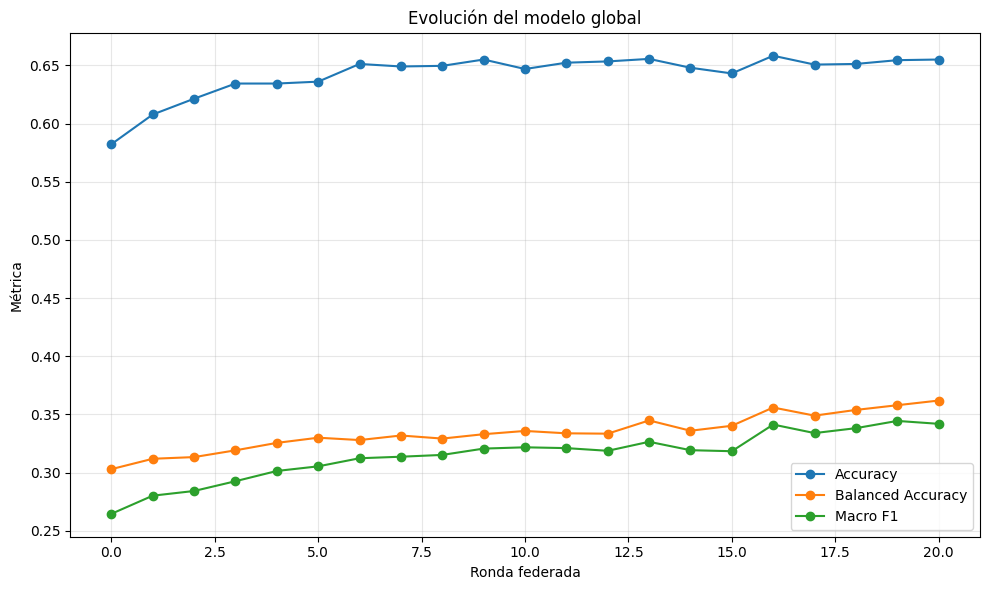

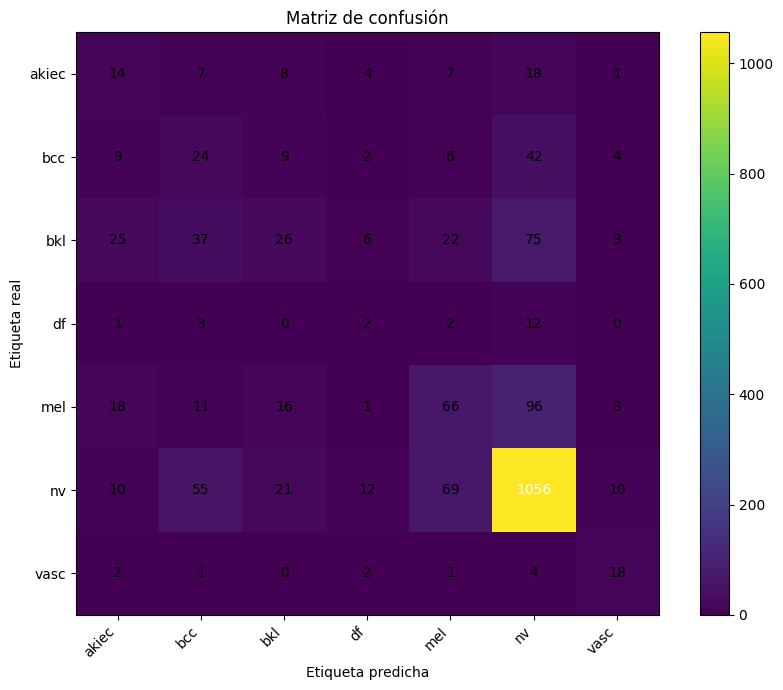


=== RESUMEN FINAL ===
 round  accuracy  balanced_accuracy  macro_f1  num_clients  num_images
    11  0.652363           0.333746  0.321021           30         360
    12  0.653449           0.333439  0.318712           30         360
    13  0.655622           0.344829  0.326466           30         360
    14  0.648017           0.335965  0.319238           30         360
    15  0.643129           0.340222  0.318356           30         360
    16  0.658338           0.355929  0.341280           30         360
    17  0.650733           0.348946  0.333946           30         360
    18  0.651276           0.353860  0.338173           30         360
    19  0.654536           0.357902  0.344406           30         360
    20  0.655079           0.361916  0.341902           30         360

=== MEJOR CHECKPOINT ===
Mejor balanced_accuracy: ronda 20 | acc=0.6551 | bal_acc=0.3619 | macro_f1=0.3419
Mejor macro_f1: ronda 19 | acc=0.6545 | bal_acc=0.3579 | macro_f1=0.3444
Modelo final: a

In [6]:
# ============================================================
# MAIN
# ============================================================


config = FederatedExperimentConfig(
    seed_size=500,
    test_size=0.20,
    rounds=20,
    clients_per_round=30,
    local_images_per_client=12,
    local_epochs=1,
    client_class_bias=0.60,
    privacy_noise_std=0.0,
    server_lr=0.30,
    early_stopping_metric="balanced_accuracy",
    early_stopping_patience=5,
    random_state=42,
)

builder = FeatureDatasetBuilder(
    metadata_path=METADATA_PATH,
    images_dir=IMAGES_DIR,
    vision=VisionPipeline(),
)

df_features = builder.build_or_load(FEATURES_CACHE_PATH)

if df_features.empty:
    raise RuntimeError("No se pudieron extraer features válidas.")

LOGGER.info("Dataset de features disponible: %d imágenes válidas", len(df_features))
LOGGER.info("Distribución por clase:\n%s", df_features["dx"].value_counts())

experiment = FederatedExperiment(df_features=df_features, config=config)
result = experiment.run()

result.final_model.save(FINAL_MODEL_PATH)
result.best_balanced_model.save(BEST_BAL_MODEL_PATH)
result.best_macro_f1_model.save(BEST_F1_MODEL_PATH)
result.history_df.to_csv(HISTORY_PATH, index=False)
plot_history(result.history_df, PLOT_PATH)

X_test, y_test = df_to_xy(result.test_df)
best_details = result.best_balanced_model.classification_details(X_test, y_test)

report_text = classification_report(
    best_details["y_true"],
    best_details["y_pred"],
    labels=best_details["labels"],
    zero_division=0,
)
with open(REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(report_text)

plot_confusion_matrix(
    best_details["confusion_matrix"],
    best_details["labels"],
    CONFUSION_PATH,
)

final_metrics = result.final_model.evaluate(X_test, y_test)
best_bal_metrics = result.best_balanced_model.evaluate(X_test, y_test)
best_f1_metrics = result.best_macro_f1_model.evaluate(X_test, y_test)

LOGGER.info("Modelo final guardado en: %s", FINAL_MODEL_PATH)
LOGGER.info("Mejor modelo por balanced_accuracy guardado en: %s", BEST_BAL_MODEL_PATH)
LOGGER.info("Mejor modelo por macro_f1 guardado en: %s", BEST_F1_MODEL_PATH)
LOGGER.info("Histórico guardado en: %s", HISTORY_PATH)
LOGGER.info("Gráfica guardada en: %s", PLOT_PATH)
LOGGER.info("Classification report guardado en: %s", REPORT_PATH)
LOGGER.info("Matriz de confusión guardada en: %s", CONFUSION_PATH)

print("\n=== RESUMEN FINAL ===")
print(result.history_df.tail(10).to_string(index=False))

print("\n=== MEJOR CHECKPOINT ===")
print(
    f"Mejor balanced_accuracy: ronda {result.best_balanced_round} | "
    f"acc={best_bal_metrics['accuracy']:.4f} | "
    f"bal_acc={best_bal_metrics['balanced_accuracy']:.4f} | "
    f"macro_f1={best_bal_metrics['macro_f1']:.4f}"
)
print(
    f"Mejor macro_f1: ronda {result.best_macro_f1_round} | "
    f"acc={best_f1_metrics['accuracy']:.4f} | "
    f"bal_acc={best_f1_metrics['balanced_accuracy']:.4f} | "
    f"macro_f1={best_f1_metrics['macro_f1']:.4f}"
)
print(
    f"Modelo final: "
    f"acc={final_metrics['accuracy']:.4f} | "
    f"bal_acc={final_metrics['balanced_accuracy']:.4f} | "
    f"macro_f1={final_metrics['macro_f1']:.4f}"
)

print("\n=== CLASSIFICATION REPORT (mejor balanced_accuracy) ===")
print(report_text)
